<a href="https://colab.research.google.com/github/taissa-arruda/prog_estat/blob/main/Resolu%C3%A7%C3%A3o_labs/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercício 1**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

M = 5000
valores_n = [5, 30, 100, 500]

# Referência: Normal(0,1) gerada pelo numpy (pedida no item 2 do enunciado)
normal_padrao = np.random.normal(size=M)

def plota_zn(Zn, titulo):
    plt.hist(Zn, bins=30, density=True, alpha=0.6, label='Zn')
    plt.hist(normal_padrao, bins=30, density=True, alpha=0.4, label='N(0,1)')
    plt.title(titulo)
    plt.legend()
    plt.show()

**Uniforme**

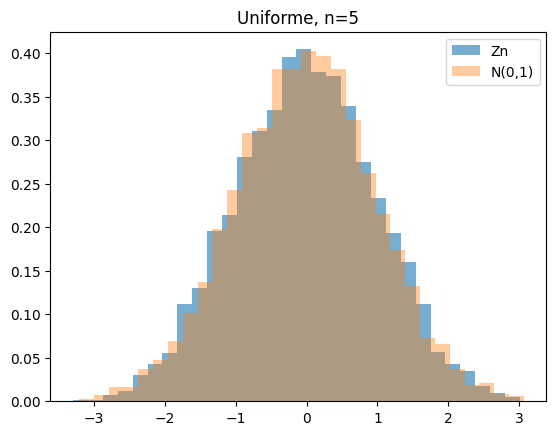

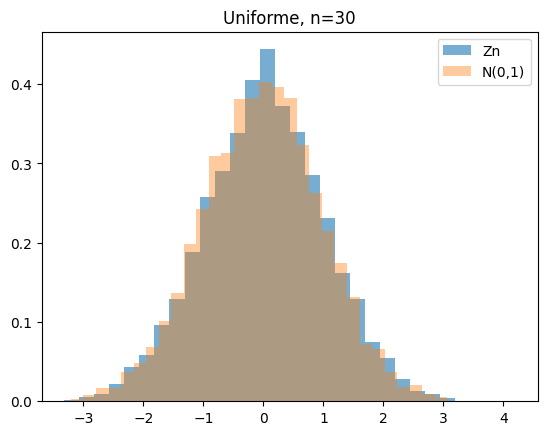

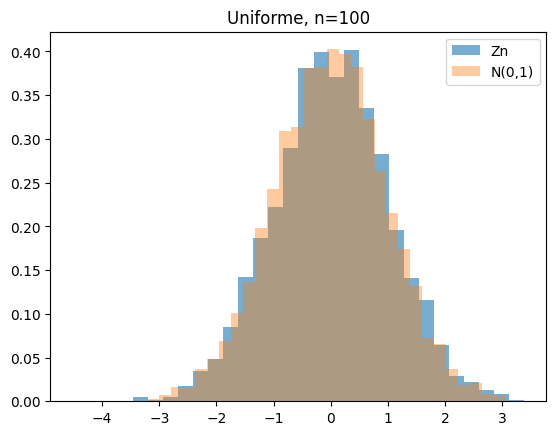

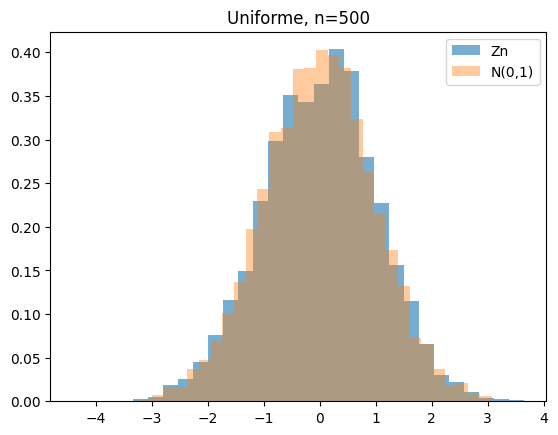

In [ ]:
mu = 0.5
sigma = (1/12) ** .5

for n in valores_n:
    amostras = np.random.uniform(size=(M, n))
    Zn = n**.5 * (np.mean(amostras, axis=1) - mu) / sigma
    plota_zn(Zn, f'Uniforme, n={n}')

**Bernoulli**

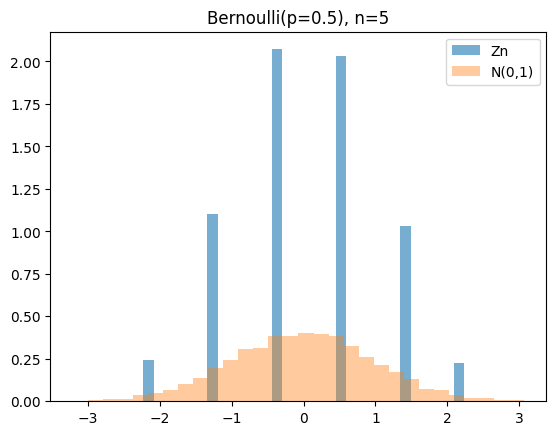

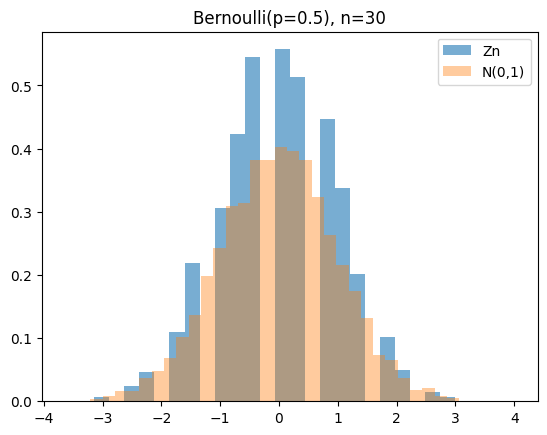

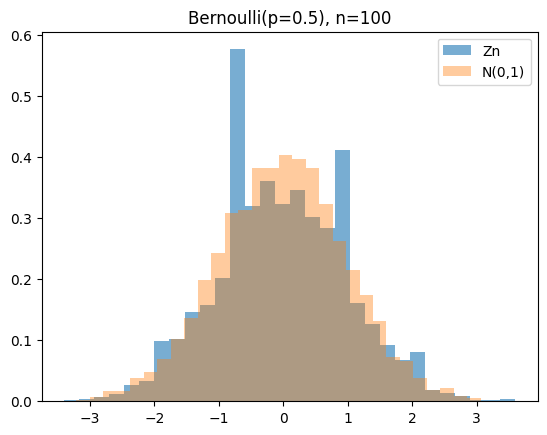

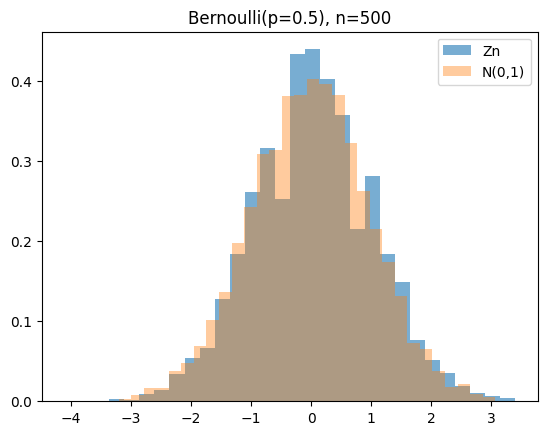

In [ ]:
p = 0.5
mu = p
sigma = (p * (1 - p)) ** .5

for n in valores_n:
    u = np.random.uniform(size=(M, n))
    amostras = (u < p).astype(int)
    Zn = n**.5 * (np.mean(amostras, axis=1) - mu) / sigma
    plota_zn(Zn, f'Bernoulli(p={p}), n={n}')

**Geométrica**

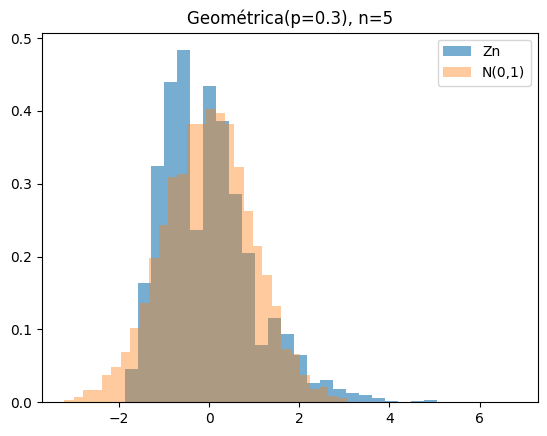

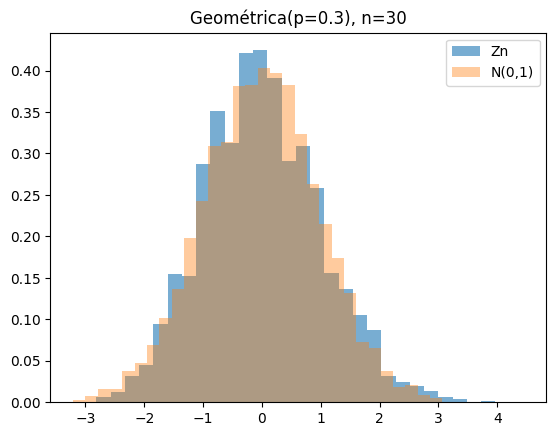

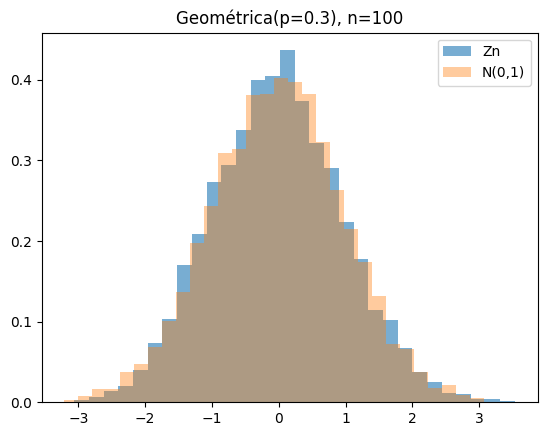

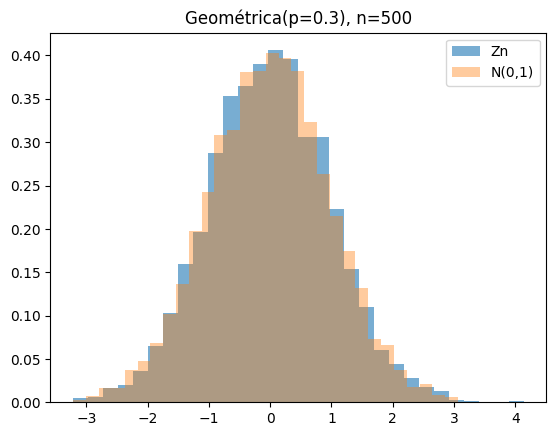

In [ ]:
p = 0.3
mu = 1 / p
sigma = ((1 - p) / p**2) ** .5

for n in valores_n:
    u = np.random.uniform(size=(M, n))
    amostras = np.ceil(np.log(1 - u) / np.log(1 - p))
    Zn = n**.5 * (np.mean(amostras, axis=1) - mu) / sigma
    plota_zn(Zn, f'Geométrica(p={p}), n={n}')

**Poisson**

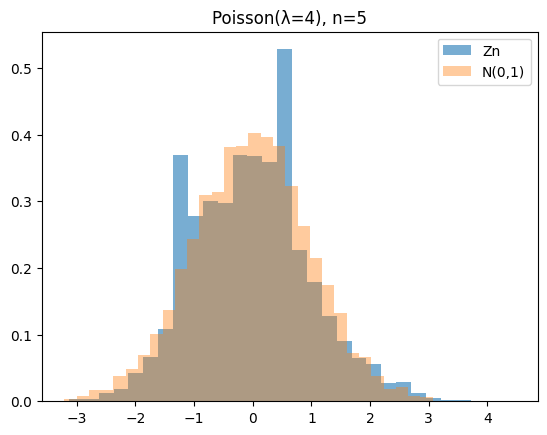

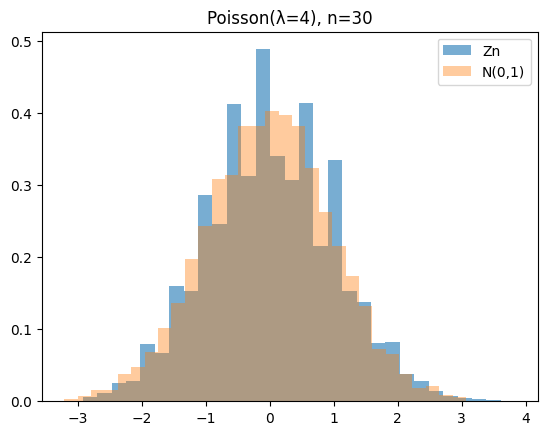

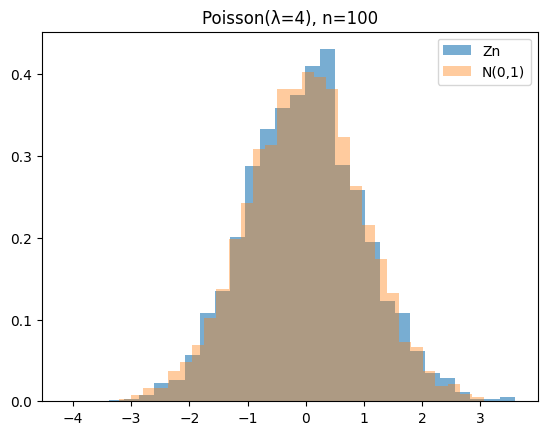

In [ ]:
def poisson_recursiva(lam):
    U = np.random.uniform()
    i = 0
    pi = np.exp(-lam)
    F = pi
    while U > F:
        pi = (lam / (i + 1)) * pi
        i += 1
        F += pi
    return i

lam = 4
mu = lam
sigma = lam ** .5

for n in [5, 30, 100]:   # sem o 500, pra não demorar
    amostras = np.array([[poisson_recursiva(lam) for _ in range(n)] for _ in range(M)])
    Zn = n**.5 * (np.mean(amostras, axis=1) - mu) / sigma
    plota_zn(Zn, f'Poisson(λ={lam}), n={n}')

**Exercício 2**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

lam = 4
M = 5000
valores_n = [5, 20, 100, 1000]

**Itens 1, 2 e 3**

n=5: média=3.98, variância=0.83 (esperado: 4)


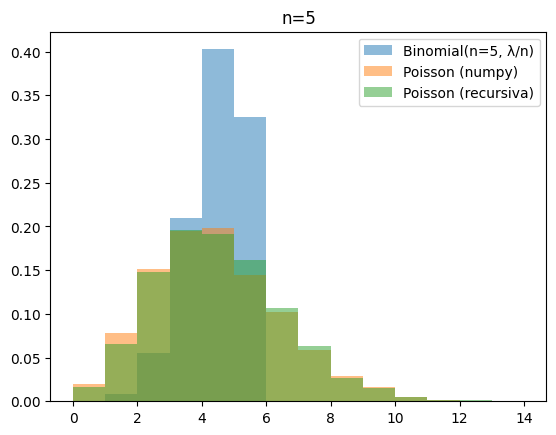

n=20: média=4.01, variância=3.21 (esperado: 4)


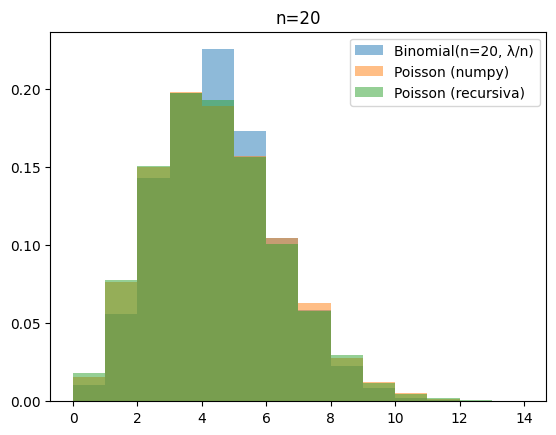

n=100: média=3.99, variância=3.73 (esperado: 4)


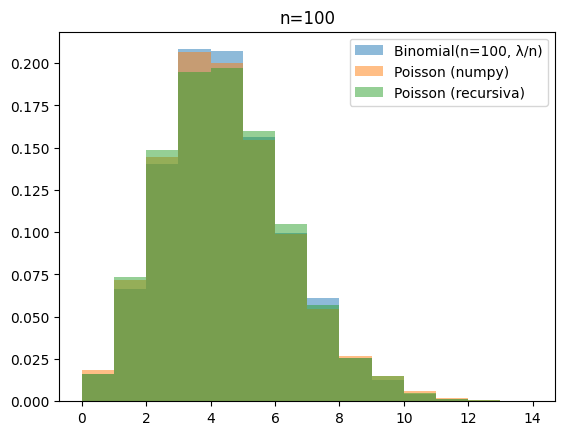

n=1000: média=4.04, variância=4.03 (esperado: 4)


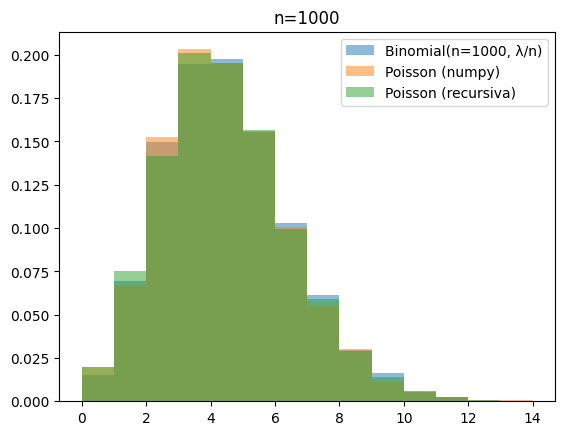

In [ ]:
def poisson_recursiva(lam):
    U = np.random.uniform()
    i = 0
    pi = np.exp(-lam)
    F = pi
    while U > F:
        pi = (lam / (i + 1)) * pi
        i += 1
        F += pi
    return i

for n in valores_n:
    p = lam / n
    u = np.random.uniform(size=(M, n))
    binomial = np.sum(u < p, axis=1)

    poisson_np = np.random.poisson(lam, M)
    poisson_rec = np.array([poisson_recursiva(lam) for _ in range(M)])

    print(f'n={n}: média={np.mean(binomial):.2f}, variância={np.var(binomial):.2f} (esperado: {lam})')

    plt.hist(binomial, bins=range(15), alpha=0.5, density=True, label=f'Binomial(n={n}, λ/n)')
    plt.hist(poisson_np, bins=range(15), alpha=0.5, density=True, label='Poisson (numpy)')
    plt.hist(poisson_rec, bins=range(15), alpha=0.5, density=True, label='Poisson (recursiva)')
    plt.legend()
    plt.title(f'n={n}')
    plt.show()

**Item 4**

In [ ]:
for n in valores_n:
    inicio = time.time()
    p = lam / n
    u = np.random.uniform(size=(M, n))
    binomial = np.sum(u < p, axis=1)
    tempo_binomial = time.time() - inicio

    inicio = time.time()
    poisson_rec = np.array([poisson_recursiva(lam) for _ in range(M)])
    tempo_recursivo = time.time() - inicio

    print(f'n={n}: tempo binomial={tempo_binomial:.4f}s, tempo recursivo={tempo_recursivo:.4f}s')

n=5: tempo binomial=0.0012s, tempo recursivo=0.0306s
n=20: tempo binomial=0.0017s, tempo recursivo=0.0327s
n=100: tempo binomial=0.0067s, tempo recursivo=0.0313s
n=1000: tempo binomial=0.0663s, tempo recursivo=0.0313s


**Item 5**

Com n pequeno (n=5), p= lam/n fica alto (0,8), e a Binomial ainda fica um pouco diferente da Poisson. Conforme n cresce (20, 100, 1000), p diminui, e os três histogramas (Binomial, Poisson numpy e Poisson recursiva) ficam praticamente sobrepostos, confirmando que quando n aumenta e p= lam/n diminui na mesma proporção a Binomial(n,p) se aproxima de uma Poisson(lam).

Sobre o tempo: a Binomial fica mais lenta conforme n aumenta, já que precisa gerar n uniformes para cada repetição. Já o método recursivo tem tempo praticamente constante, porque não depende de n, só de lam. Como vantagem e desvantagem: a Binomial é mais simples de entender, mas custa mais para n grande; a recursiva é mais eficiente nesse sentido, mas tem uma lógica mais complexa (usa um while que soma probabilidades até achar o valor sorteado).